# Chapter 4: Information Theory

This notebook covers the information theory concepts that underpin many machine learning algorithms:

1. Self-Information and Entropy
2. KL Divergence
3. Cross-Entropy
4. Mutual Information
5. Practical: Language Model Perplexity

**Why Information Theory Matters for ML:**
- **Cross-entropy loss** is the standard loss function for classification tasks
- **KL divergence** appears in VAEs (variational autoencoders) as the regularization term
- **Mutual information** is used for feature selection and understanding model representations
- **Perplexity** is the key metric for evaluating language models

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import rel_entr
import ipywidgets as widgets
from ipywidgets import interact, interactive

# Configure matplotlib
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12
np.random.seed(42)

## 1. Self-Information and Entropy

**Self-information** (or surprisal) measures how surprising an event is:

$$I(x) = -\log_2 P(x)$$

- Rare events (low probability) have high information content
- Common events (high probability) have low information content

**Entropy** is the expected self-information:

$$H(X) = -\sum_{x} P(x) \log_2 P(x) = \mathbb{E}[I(X)]$$

Entropy measures the average uncertainty or "surprise" in a distribution.

In [2]:
def self_information(p, base=2):
    """
    Compute self-information (surprisal) of an event with probability p.
    
    Parameters:
        p: probability of the event (0 < p <= 1)
        base: logarithm base (2 for bits, e for nats)
    
    Returns:
        Self-information in bits (if base=2) or nats (if base=e)
    """
    if p <= 0:
        return np.inf
    return -np.log(p) / np.log(base)

# Examples of self-information
events = [
    ("Fair coin heads", 0.5),
    ("Rolling a 6 on fair die", 1/6),
    ("Very likely event", 0.99),
    ("Rare event", 0.01),
    ("Certain event", 1.0),
]

print("Self-Information Examples:")
print("-" * 50)
for name, p in events:
    info = self_information(p)
    print(f"{name:30s} P={p:.4f}  I={info:.4f} bits")

Self-Information Examples:
--------------------------------------------------
Fair coin heads                P=0.5000  I=1.0000 bits
Rolling a 6 on fair die        P=0.1667  I=2.5850 bits
Very likely event              P=0.9900  I=0.0145 bits
Rare event                     P=0.0100  I=6.6439 bits
Certain event                  P=1.0000  I=-0.0000 bits


In [3]:
def entropy(p, base=2):
    """
    Compute the entropy of a discrete probability distribution.
    
    Parameters:
        p: array of probabilities (must sum to 1)
        base: logarithm base (2 for bits, e for nats)
    
    Returns:
        Entropy in bits (if base=2) or nats (if base=e)
    """
    p = np.asarray(p)
    # Filter out zero probabilities to avoid log(0)
    p = p[p > 0]
    return -np.sum(p * np.log(p) / np.log(base))

# Compare entropy of different distributions
distributions = {
    "Uniform (4 outcomes)": np.array([0.25, 0.25, 0.25, 0.25]),
    "Peaked": np.array([0.7, 0.1, 0.1, 0.1]),
    "Very peaked": np.array([0.97, 0.01, 0.01, 0.01]),
    "Deterministic": np.array([1.0, 0.0, 0.0, 0.0]),
}

print("Entropy Comparison:")
print("-" * 60)
for name, p in distributions.items():
    H = entropy(p)
    print(f"{name:25s} p={p}  H={H:.4f} bits")

print("\nKey insight: Maximum entropy = log2(n) for n equally likely outcomes")
print(f"Maximum entropy for 4 outcomes: {np.log2(4):.4f} bits")

Entropy Comparison:
------------------------------------------------------------
Uniform (4 outcomes)      p=[0.25 0.25 0.25 0.25]  H=2.0000 bits
Peaked                    p=[0.7 0.1 0.1 0.1]  H=1.3568 bits
Very peaked               p=[0.97 0.01 0.01 0.01]  H=0.2419 bits
Deterministic             p=[1. 0. 0. 0.]  H=-0.0000 bits

Key insight: Maximum entropy = log2(n) for n equally likely outcomes
Maximum entropy for 4 outcomes: 2.0000 bits


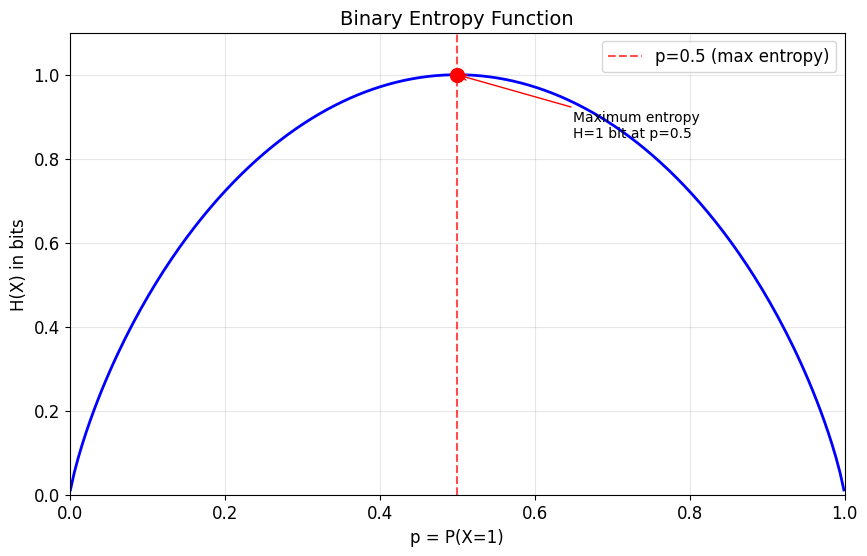

Observations:
- Maximum entropy (1 bit) occurs at p=0.5 (maximum uncertainty)
- Entropy is 0 at p=0 or p=1 (no uncertainty, outcome is certain)
- The curve is symmetric around p=0.5


In [4]:
# Binary entropy function: H(p) for a Bernoulli random variable
def binary_entropy(p):
    """Entropy of a binary variable with P(X=1) = p."""
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

# Plot binary entropy
p_values = np.linspace(0.001, 0.999, 200)
H_values = [binary_entropy(p) for p in p_values]

plt.figure(figsize=(10, 6))
plt.plot(p_values, H_values, 'b-', linewidth=2)
plt.xlabel('p = P(X=1)', fontsize=12)
plt.ylabel('H(X) in bits', fontsize=12)
plt.title('Binary Entropy Function', fontsize=14)
plt.grid(True, alpha=0.3)

# Mark key points
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='p=0.5 (max entropy)')
plt.scatter([0.5], [1.0], color='red', s=100, zorder=5)
plt.annotate('Maximum entropy\nH=1 bit at p=0.5', xy=(0.5, 1.0), 
             xytext=(0.65, 0.85), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='red'))

plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1.1)
plt.show()

print("Observations:")
print("- Maximum entropy (1 bit) occurs at p=0.5 (maximum uncertainty)")
print("- Entropy is 0 at p=0 or p=1 (no uncertainty, outcome is certain)")
print("- The curve is symmetric around p=0.5")

In [5]:
# Interactive: Compare entropy of different distributions
def plot_entropy_comparison(p1=0.25, p2=0.25, p3=0.25):
    """
    Compare distributions with different entropy levels.
    p4 is computed to ensure probabilities sum to 1.
    """
    p4 = max(0, 1 - p1 - p2 - p3)
    if p1 + p2 + p3 > 1:
        print("Warning: probabilities exceed 1, adjusting...")
        total = p1 + p2 + p3
        p1, p2, p3 = p1/total, p2/total, p3/total
        p4 = 0
    
    probs = np.array([p1, p2, p3, p4])
    H = entropy(probs)
    H_max = np.log2(4)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of distribution
    ax = axes[0]
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, 4))
    bars = ax.bar(['A', 'B', 'C', 'D'], probs, color=colors, edgecolor='black')
    ax.set_ylabel('Probability')
    ax.set_title(f'Distribution (H = {H:.3f} bits)')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.25, color='r', linestyle='--', alpha=0.5, label='Uniform')
    ax.legend()
    
    # Add probability labels
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{p:.2f}', ha='center', va='bottom')
    
    # Entropy gauge
    ax = axes[1]
    ax.barh(['Entropy'], [H], color='steelblue', height=0.5)
    ax.barh(['Max Entropy'], [H_max], color='lightgray', height=0.5)
    ax.set_xlim(0, 2.2)
    ax.set_xlabel('Entropy (bits)')
    ax.set_title(f'Entropy: {H:.3f} / {H_max:.3f} bits ({100*H/H_max:.1f}% of maximum)')
    
    plt.tight_layout()
    plt.show()

interact(plot_entropy_comparison,
         p1=widgets.FloatSlider(min=0, max=1, step=0.05, value=0.25, description='P(A)'),
         p2=widgets.FloatSlider(min=0, max=1, step=0.05, value=0.25, description='P(B)'),
         p3=widgets.FloatSlider(min=0, max=1, step=0.05, value=0.25, description='P(C)'));

interactive(children=(FloatSlider(value=0.25, description='P(A)', max=1.0, step=0.05), FloatSlider(value=0.25,…

## 2. KL Divergence

**Kullback-Leibler divergence** measures how one probability distribution differs from another:

$$D_{KL}(P \| Q) = \sum_{x} P(x) \log \frac{P(x)}{Q(x)}$$

Key properties:
- $D_{KL}(P \| Q) \geq 0$ (always non-negative)
- $D_{KL}(P \| Q) = 0$ if and only if $P = Q$
- **Not symmetric**: $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$

**ML Applications:**
- VAE loss: $\mathcal{L} = \text{reconstruction} + \beta \cdot D_{KL}(q(z|x) \| p(z))$
- Knowledge distillation: matching teacher and student distributions

In [6]:
def kl_divergence(p, q, base=2):
    """
    Compute KL divergence D_KL(P || Q).
    
    Parameters:
        p: "true" distribution
        q: "approximate" distribution
        base: logarithm base
    
    Returns:
        KL divergence value
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    
    # Handle zeros: KL is undefined if q=0 where p>0
    # Add small epsilon to avoid log(0)
    eps = 1e-10
    q = np.clip(q, eps, 1)
    
    # Only sum where p > 0
    mask = p > 0
    return np.sum(p[mask] * np.log(p[mask] / q[mask]) / np.log(base))

# Example: comparing distributions
P = np.array([0.4, 0.3, 0.2, 0.1])  # True distribution
Q1 = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform approximation
Q2 = np.array([0.35, 0.30, 0.20, 0.15])  # Close approximation
Q3 = np.array([0.1, 0.1, 0.1, 0.7])  # Poor approximation

print("KL Divergence Examples:")
print(f"P = {P}")
print("-" * 50)
print(f"D_KL(P || Q1_uniform)  = {kl_divergence(P, Q1):.4f} bits")
print(f"D_KL(P || Q2_close)    = {kl_divergence(P, Q2):.4f} bits")
print(f"D_KL(P || Q3_poor)     = {kl_divergence(P, Q3):.4f} bits")

KL Divergence Examples:
P = [0.4 0.3 0.2 0.1]
--------------------------------------------------
D_KL(P || Q1_uniform)  = 0.1536 bits
D_KL(P || Q2_close)    = 0.0186 bits
D_KL(P || Q3_poor)     = 1.1948 bits


In [7]:
# Demonstrate KL divergence asymmetry
P = np.array([0.9, 0.1])
Q = np.array([0.5, 0.5])

kl_pq = kl_divergence(P, Q)
kl_qp = kl_divergence(Q, P)

print("KL Divergence Asymmetry:")
print(f"P = {P} (peaked)")
print(f"Q = {Q} (uniform)")
print("-" * 40)
print(f"D_KL(P || Q) = {kl_pq:.4f} bits")
print(f"D_KL(Q || P) = {kl_qp:.4f} bits")
print(f"\nRatio: D_KL(Q||P) / D_KL(P||Q) = {kl_qp/kl_pq:.2f}x")

print("\nInterpretation:")
print("- D_KL(P||Q): Cost of using Q to encode data from P")
print("- D_KL(Q||P): Cost of using P to encode data from Q")
print("- These can be very different!")

KL Divergence Asymmetry:
P = [0.9 0.1] (peaked)
Q = [0.5 0.5] (uniform)
----------------------------------------
D_KL(P || Q) = 0.5310 bits
D_KL(Q || P) = 0.7370 bits

Ratio: D_KL(Q||P) / D_KL(P||Q) = 1.39x

Interpretation:
- D_KL(P||Q): Cost of using Q to encode data from P
- D_KL(Q||P): Cost of using P to encode data from Q
- These can be very different!


In [8]:
# Visualize forward vs reverse KL for Gaussian approximations
def plot_kl_gaussians(mu_q=0.0, sigma_q=1.0):
    """
    Visualize KL divergence between a bimodal distribution P
    and a Gaussian approximation Q.
    """
    x = np.linspace(-6, 6, 1000)
    
    # True distribution: mixture of two Gaussians
    P = 0.5 * stats.norm.pdf(x, -2, 0.8) + 0.5 * stats.norm.pdf(x, 2, 0.8)
    P = P / np.trapz(P, x)  # Normalize
    
    # Approximate distribution: single Gaussian
    Q = stats.norm.pdf(x, mu_q, sigma_q)
    Q = Q / np.trapz(Q, x)  # Normalize
    
    # Compute KL divergences (using numerical integration)
    eps = 1e-10
    P_safe = np.clip(P, eps, None)
    Q_safe = np.clip(Q, eps, None)
    
    kl_pq = np.trapz(P_safe * np.log(P_safe / Q_safe), x)
    kl_qp = np.trapz(Q_safe * np.log(Q_safe / P_safe), x)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left plot: distributions
    ax = axes[0]
    ax.fill_between(x, P, alpha=0.3, color='blue', label='P (true bimodal)')
    ax.plot(x, P, 'b-', linewidth=2)
    ax.fill_between(x, Q, alpha=0.3, color='red', label='Q (Gaussian approx)')
    ax.plot(x, Q, 'r-', linewidth=2)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.set_title('True Distribution P vs Approximation Q')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right plot: KL comparison
    ax = axes[1]
    bars = ax.bar(['D_KL(P||Q)\n(Forward KL)', 'D_KL(Q||P)\n(Reverse KL)'], 
                  [kl_pq, kl_qp], color=['steelblue', 'coral'])
    ax.set_ylabel('KL Divergence (nats)')
    ax.set_title('Forward vs Reverse KL')
    
    for bar, val in zip(bars, [kl_pq, kl_qp]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.3f}', ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("Forward KL (D_KL(P||Q)): Q must cover all of P's mass")
    print("  -> Tends to produce 'mean-seeking' behavior")
    print("Reverse KL (D_KL(Q||P)): Q can ignore parts of P")
    print("  -> Tends to produce 'mode-seeking' behavior")

interact(plot_kl_gaussians,
         mu_q=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0, description='Q mean'),
         sigma_q=widgets.FloatSlider(min=0.5, max=4, step=0.1, value=2.5, description='Q std'));

interactive(children=(FloatSlider(value=0.0, description='Q mean', max=3.0, min=-3.0), FloatSlider(value=2.5, …

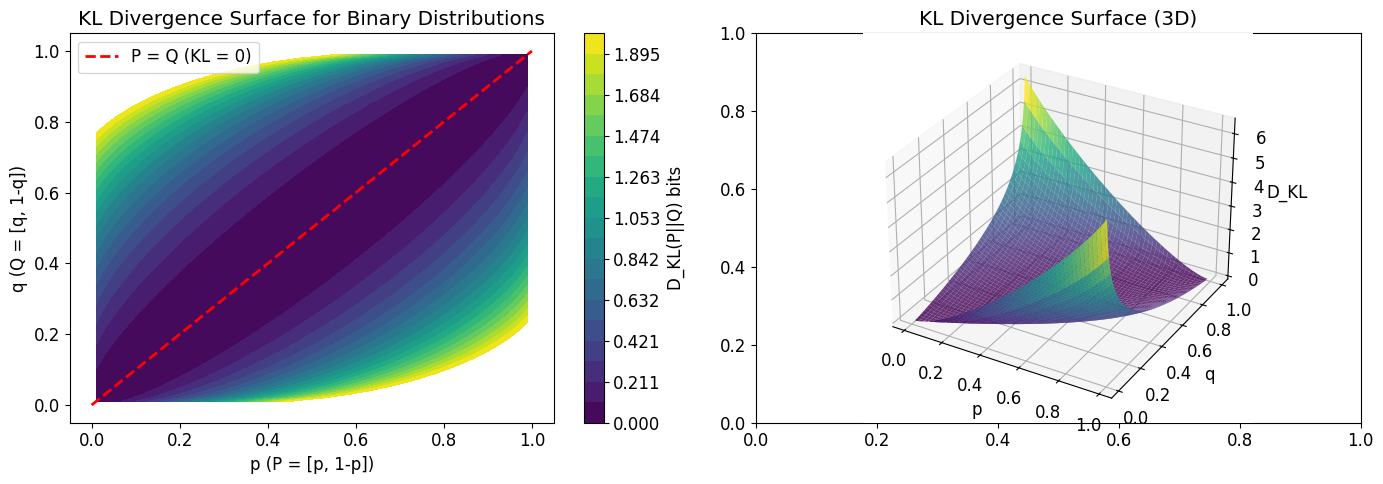

Observations:
- KL = 0 along the diagonal (when P = Q)
- KL diverges when Q assigns low probability where P is high
- The surface is not symmetric!


In [9]:
# Visualize KL divergence surface for binary distributions
# P = [p, 1-p], Q = [q, 1-q]

p_range = np.linspace(0.01, 0.99, 100)
q_range = np.linspace(0.01, 0.99, 100)
P_grid, Q_grid = np.meshgrid(p_range, q_range)

# Compute D_KL(P || Q) for each (p, q) pair
KL_surface = np.zeros_like(P_grid)
for i in range(len(p_range)):
    for j in range(len(q_range)):
        p, q = p_range[i], q_range[j]
        P_dist = np.array([p, 1-p])
        Q_dist = np.array([q, 1-q])
        KL_surface[j, i] = kl_divergence(P_dist, Q_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour plot
ax = axes[0]
levels = np.linspace(0, 2, 20)
cs = ax.contourf(P_grid, Q_grid, KL_surface, levels=levels, cmap='viridis')
plt.colorbar(cs, ax=ax, label='D_KL(P||Q) bits')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='P = Q (KL = 0)')
ax.set_xlabel('p (P = [p, 1-p])')
ax.set_ylabel('q (Q = [q, 1-q])')
ax.set_title('KL Divergence Surface for Binary Distributions')
ax.legend()

# 3D surface
ax = axes[1]
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot_surface(P_grid, Q_grid, KL_surface, cmap='viridis', alpha=0.8)
ax.set_xlabel('p')
ax.set_ylabel('q')
ax.set_zlabel('D_KL')
ax.set_title('KL Divergence Surface (3D)')

plt.tight_layout()
plt.show()

print("Observations:")
print("- KL = 0 along the diagonal (when P = Q)")
print("- KL diverges when Q assigns low probability where P is high")
print("- The surface is not symmetric!")

## 3. Cross-Entropy

**Cross-entropy** measures the average number of bits needed to encode data from distribution P using a code optimized for distribution Q:

$$H(P, Q) = -\sum_{x} P(x) \log Q(x)$$

**Key relationship:**
$$H(P, Q) = H(P) + D_{KL}(P \| Q)$$

**Why Cross-Entropy Loss in ML?**
- When training, P is the true label distribution (one-hot)
- Q is the model's predicted probabilities
- Minimizing cross-entropy is equivalent to minimizing KL divergence from true to predicted

In [10]:
def cross_entropy(p, q, base=2):
    """
    Compute cross-entropy H(P, Q).
    
    Parameters:
        p: true distribution
        q: predicted distribution
        base: logarithm base
    
    Returns:
        Cross-entropy value
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    
    eps = 1e-10
    q = np.clip(q, eps, 1)
    
    return -np.sum(p * np.log(q) / np.log(base))

# Verify relationship: H(P,Q) = H(P) + D_KL(P||Q)
P = np.array([0.7, 0.2, 0.1])
Q = np.array([0.5, 0.3, 0.2])

H_P = entropy(P)
D_KL = kl_divergence(P, Q)
H_PQ = cross_entropy(P, Q)

print("Verifying H(P,Q) = H(P) + D_KL(P||Q)")
print("-" * 40)
print(f"H(P)        = {H_P:.4f} bits")
print(f"D_KL(P||Q)  = {D_KL:.4f} bits")
print(f"H(P) + D_KL = {H_P + D_KL:.4f} bits")
print(f"H(P, Q)     = {H_PQ:.4f} bits")
print(f"\nDifference: {abs(H_PQ - (H_P + D_KL)):.2e} (numerical precision)")

Verifying H(P,Q) = H(P) + D_KL(P||Q)
----------------------------------------
H(P)        = 1.1568 bits
D_KL(P||Q)  = 0.1228 bits
H(P) + D_KL = 1.2796 bits
H(P, Q)     = 1.2796 bits

Difference: 0.00e+00 (numerical precision)


In [11]:
def cross_entropy_loss(y_true, y_pred):
    """
    Compute cross-entropy loss for classification.
    This is the standard loss function used in neural network classifiers.
    
    Parameters:
        y_true: one-hot encoded true labels (batch_size, num_classes)
        y_pred: predicted probabilities (batch_size, num_classes)
    
    Returns:
        Average cross-entropy loss over the batch
    """
    eps = 1e-10
    y_pred = np.clip(y_pred, eps, 1 - eps)
    
    # Cross-entropy for each sample
    ce = -np.sum(y_true * np.log(y_pred), axis=1)
    
    return np.mean(ce)

# Example: 3-class classification
# True labels (one-hot encoded)
y_true = np.array([
    [1, 0, 0],  # Class 0
    [0, 1, 0],  # Class 1
    [0, 0, 1],  # Class 2
    [1, 0, 0],  # Class 0
])

# Different quality predictions
y_pred_good = np.array([
    [0.9, 0.05, 0.05],
    [0.1, 0.8, 0.1],
    [0.05, 0.05, 0.9],
    [0.85, 0.1, 0.05],
])

y_pred_poor = np.array([
    [0.4, 0.3, 0.3],
    [0.3, 0.4, 0.3],
    [0.3, 0.3, 0.4],
    [0.4, 0.3, 0.3],
])

y_pred_random = np.array([
    [0.33, 0.33, 0.34],
    [0.33, 0.33, 0.34],
    [0.33, 0.33, 0.34],
    [0.33, 0.33, 0.34],
])

print("Cross-Entropy Loss for Different Prediction Quality:")
print("-" * 50)
print(f"Good predictions:   Loss = {cross_entropy_loss(y_true, y_pred_good):.4f}")
print(f"Poor predictions:   Loss = {cross_entropy_loss(y_true, y_pred_poor):.4f}")
print(f"Random predictions: Loss = {cross_entropy_loss(y_true, y_pred_random):.4f}")
print(f"\nNote: Lower loss = better predictions")
print(f"Random guessing gives loss = log(3) = {np.log(3):.4f}")

Cross-Entropy Loss for Different Prediction Quality:
--------------------------------------------------
Good predictions:   Loss = 0.1491
Poor predictions:   Loss = 0.9163
Random predictions: Loss = 1.1012

Note: Lower loss = better predictions
Random guessing gives loss = log(3) = 1.0986


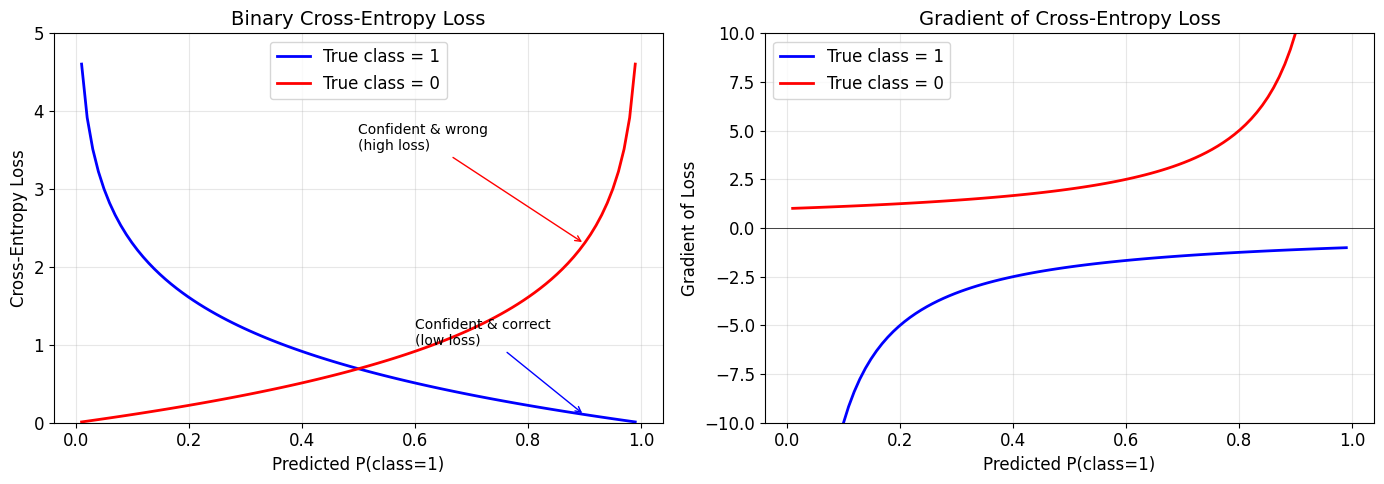

Key insights:
- Wrong confident predictions are heavily penalized (steep loss)
- Gradient is larger for more confident wrong predictions
- This encourages the model to 'unlearn' confident mistakes quickly


In [12]:
# Visualize cross-entropy loss for binary classification
def plot_ce_loss_surface():
    """
    Visualize how cross-entropy loss changes with predicted probability
    for both classes.
    """
    p_pred = np.linspace(0.01, 0.99, 100)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Loss curves for each true class
    ax = axes[0]
    
    # True class = 1
    loss_class1 = -np.log(p_pred)
    ax.plot(p_pred, loss_class1, 'b-', linewidth=2, label='True class = 1')
    
    # True class = 0 (so we predict 1-p)
    loss_class0 = -np.log(1 - p_pred)
    ax.plot(p_pred, loss_class0, 'r-', linewidth=2, label='True class = 0')
    
    ax.set_xlabel('Predicted P(class=1)', fontsize=12)
    ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
    ax.set_title('Binary Cross-Entropy Loss', fontsize=14)
    ax.set_ylim(0, 5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Annotations
    ax.annotate('Confident & correct\n(low loss)', xy=(0.9, 0.1), fontsize=10,
                xytext=(0.6, 1), arrowprops=dict(arrowstyle='->', color='blue'))
    ax.annotate('Confident & wrong\n(high loss)', xy=(0.9, 2.3), fontsize=10,
                xytext=(0.5, 3.5), arrowprops=dict(arrowstyle='->', color='red'))
    
    # Right: Gradient of loss
    ax = axes[1]
    
    # Gradient for true class = 1: d/dp[-log(p)] = -1/p
    grad_class1 = -1 / p_pred
    ax.plot(p_pred, grad_class1, 'b-', linewidth=2, label='True class = 1')
    
    # Gradient for true class = 0: d/dp[-log(1-p)] = 1/(1-p)
    grad_class0 = 1 / (1 - p_pred)
    ax.plot(p_pred, grad_class0, 'r-', linewidth=2, label='True class = 0')
    
    ax.set_xlabel('Predicted P(class=1)', fontsize=12)
    ax.set_ylabel('Gradient of Loss', fontsize=12)
    ax.set_title('Gradient of Cross-Entropy Loss', fontsize=14)
    ax.set_ylim(-10, 10)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Key insights:")
    print("- Wrong confident predictions are heavily penalized (steep loss)")
    print("- Gradient is larger for more confident wrong predictions")
    print("- This encourages the model to 'unlearn' confident mistakes quickly")

plot_ce_loss_surface()

## 4. Mutual Information

**Mutual Information** measures the amount of information shared between two random variables:

$$I(X; Y) = \sum_{x,y} P(x, y) \log \frac{P(x, y)}{P(x)P(y)}$$

Equivalent formulations:
- $I(X; Y) = H(X) - H(X|Y) = H(Y) - H(Y|X)$
- $I(X; Y) = D_{KL}(P(X,Y) \| P(X)P(Y))$

**ML Applications:**
- Feature selection: select features with high MI with the target
- Understanding neural network representations
- InfoGAN: learning disentangled representations

In [13]:
def mutual_information(joint_prob):
    """
    Compute mutual information I(X; Y) from joint probability distribution.
    
    Parameters:
        joint_prob: 2D array where joint_prob[i,j] = P(X=i, Y=j)
    
    Returns:
        Mutual information in bits
    """
    joint_prob = np.asarray(joint_prob, dtype=float)
    
    # Marginal distributions
    p_x = np.sum(joint_prob, axis=1)  # P(X)
    p_y = np.sum(joint_prob, axis=0)  # P(Y)
    
    # Compute MI
    mi = 0
    for i in range(joint_prob.shape[0]):
        for j in range(joint_prob.shape[1]):
            if joint_prob[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mi += joint_prob[i, j] * np.log2(
                    joint_prob[i, j] / (p_x[i] * p_y[j])
                )
    return mi

# Example 1: Independent variables (MI = 0)
# P(X,Y) = P(X)P(Y)
p_x = np.array([0.3, 0.7])
p_y = np.array([0.4, 0.6])
joint_independent = np.outer(p_x, p_y)

print("Example 1: Independent Variables")
print(f"Joint distribution:\n{joint_independent}")
print(f"Mutual Information: {mutual_information(joint_independent):.6f} bits")

# Example 2: Perfectly dependent (Y = X)
joint_perfect = np.array([
    [0.3, 0.0],
    [0.0, 0.7]
])

print("\nExample 2: Perfectly Dependent (Y = X)")
print(f"Joint distribution:\n{joint_perfect}")
print(f"Mutual Information: {mutual_information(joint_perfect):.4f} bits")
print(f"H(X) = H(Y) = {entropy(p_x):.4f} bits (MI equals entropy when perfectly dependent)")

# Example 3: Partial dependence
joint_partial = np.array([
    [0.25, 0.05],
    [0.10, 0.60]
])

print("\nExample 3: Partial Dependence")
print(f"Joint distribution:\n{joint_partial}")
print(f"Mutual Information: {mutual_information(joint_partial):.4f} bits")

Example 1: Independent Variables
Joint distribution:
[[0.12 0.18]
 [0.28 0.42]]
Mutual Information: 0.000000 bits

Example 2: Perfectly Dependent (Y = X)
Joint distribution:
[[0.3 0. ]
 [0.  0.7]]
Mutual Information: 0.8813 bits
H(X) = H(Y) = 0.8813 bits (MI equals entropy when perfectly dependent)

Example 3: Partial Dependence
Joint distribution:
[[0.25 0.05]
 [0.1  0.6 ]]
Mutual Information: 0.3249 bits


Comparing Mutual Information vs Correlation:
------------------------------------------------------------
Independent           MI = 0.102 bits,  Correlation = -0.018
Linear                MI = 1.871 bits,  Correlation = 0.969
Nonlinear (Y=X^2)     MI = 1.571 bits,  Correlation = -0.038
Circular              MI = 1.036 bits,  Correlation = -0.004


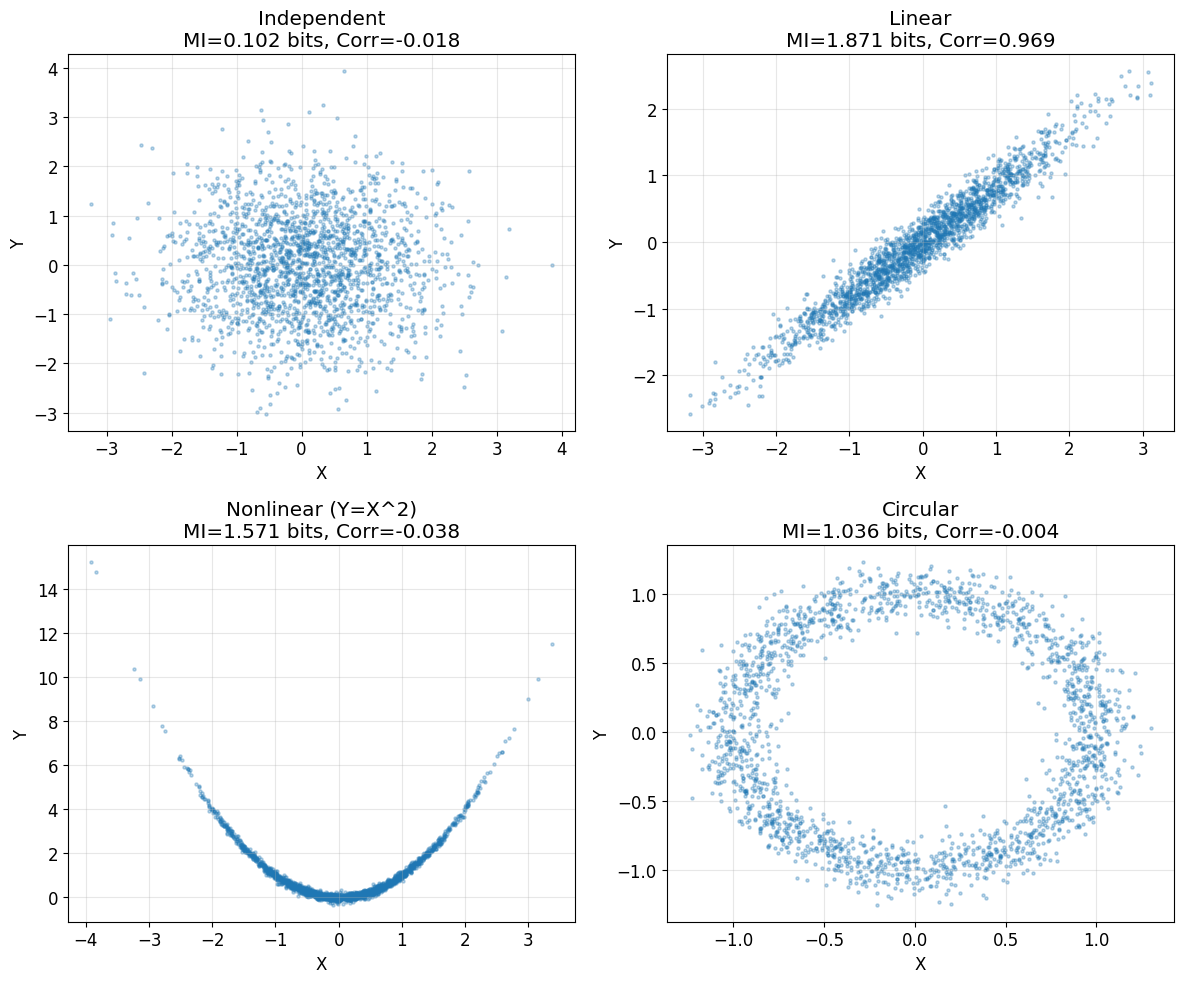


Key insight: MI detects nonlinear dependencies that correlation misses!
- Correlation only measures linear relationships
- MI captures any statistical dependence


In [14]:
# Detecting dependencies between variables using MI
def estimate_mi_from_samples(x, y, bins=10):
    """
    Estimate mutual information from samples using histogram-based approach.
    
    Parameters:
        x, y: arrays of samples
        bins: number of bins for discretization
    
    Returns:
        Estimated mutual information
    """
    # Create 2D histogram (joint distribution)
    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    joint_prob = joint_hist / np.sum(joint_hist)
    
    return mutual_information(joint_prob)

# Generate samples with different relationships
np.random.seed(42)
n_samples = 2000

# Independent
x_ind = np.random.randn(n_samples)
y_ind = np.random.randn(n_samples)

# Linear dependence
x_lin = np.random.randn(n_samples)
y_lin = 0.8 * x_lin + 0.2 * np.random.randn(n_samples)

# Nonlinear dependence (Y = X^2 + noise)
x_nonlin = np.random.randn(n_samples)
y_nonlin = x_nonlin**2 + 0.1 * np.random.randn(n_samples)

# Circular dependence
theta = 2 * np.pi * np.random.rand(n_samples)
x_circ = np.cos(theta) + 0.1 * np.random.randn(n_samples)
y_circ = np.sin(theta) + 0.1 * np.random.randn(n_samples)

# Compute MI and correlation
relationships = [
    ("Independent", x_ind, y_ind),
    ("Linear", x_lin, y_lin),
    ("Nonlinear (Y=X^2)", x_nonlin, y_nonlin),
    ("Circular", x_circ, y_circ),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

print("Comparing Mutual Information vs Correlation:")
print("-" * 60)

for ax, (name, x, y) in zip(axes, relationships):
    mi = estimate_mi_from_samples(x, y, bins=20)
    corr = np.corrcoef(x, y)[0, 1]
    
    ax.scatter(x, y, alpha=0.3, s=5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{name}\nMI={mi:.3f} bits, Corr={corr:.3f}')
    ax.grid(True, alpha=0.3)
    
    print(f"{name:20s}  MI = {mi:.3f} bits,  Correlation = {corr:.3f}")

plt.tight_layout()
plt.show()

print("\nKey insight: MI detects nonlinear dependencies that correlation misses!")
print("- Correlation only measures linear relationships")
print("- MI captures any statistical dependence")

## 5. Practical: Language Model Perplexity

**Perplexity** is the standard metric for evaluating language models:

$$\text{PPL} = 2^{H(P, Q)} = 2^{-\frac{1}{N}\sum_{i=1}^{N} \log_2 Q(w_i | w_{<i})}$$

Where:
- $Q(w_i | w_{<i})$ is the model's predicted probability of word $w_i$
- $N$ is the total number of words

**Interpretation:**
- Perplexity is the "effective vocabulary size" the model is uncertain about
- Lower perplexity = better language model
- A model with PPL=100 is "as confused as if choosing uniformly among 100 words"

In [15]:
def compute_perplexity(probs):
    """
    Compute perplexity from a sequence of probabilities.
    
    Parameters:
        probs: array of probabilities P(w_i | context) for each word
    
    Returns:
        Perplexity value
    """
    probs = np.asarray(probs)
    eps = 1e-10
    probs = np.clip(probs, eps, 1)
    
    # Cross-entropy (average negative log probability)
    ce = -np.mean(np.log2(probs))
    
    # Perplexity = 2^(cross-entropy)
    return 2 ** ce

# Example: evaluating different "models" on the same text
# Simulated probabilities for each word in sequence

# Good model: assigns high probability to actual words
probs_good = [0.8, 0.7, 0.9, 0.6, 0.85, 0.75, 0.8, 0.7]

# Medium model: moderate confidence
probs_medium = [0.3, 0.4, 0.35, 0.25, 0.4, 0.3, 0.35, 0.3]

# Poor model: low confidence (nearly uniform over vocab)
probs_poor = [0.05, 0.08, 0.04, 0.06, 0.05, 0.07, 0.04, 0.05]

# Random baseline (uniform over 10000 word vocab)
probs_random = [1/10000] * 8

print("Language Model Perplexity Comparison:")
print("-" * 50)
print(f"Good model:    PPL = {compute_perplexity(probs_good):.2f}")
print(f"Medium model:  PPL = {compute_perplexity(probs_medium):.2f}")
print(f"Poor model:    PPL = {compute_perplexity(probs_poor):.2f}")
print(f"Random (10k vocab): PPL = {compute_perplexity(probs_random):.2f}")

print("\nInterpretation:")
print("- Lower perplexity = better language model")
print("- PPL=10 means model is 'choosing among ~10 equally likely words'")
print("- State-of-the-art models achieve PPL < 20 on common benchmarks")

Language Model Perplexity Comparison:
--------------------------------------------------
Good model:    PPL = 1.32
Medium model:  PPL = 3.05
Poor model:    PPL = 18.69
Random (10k vocab): PPL = 10000.00

Interpretation:
- Lower perplexity = better language model
- PPL=10 means model is 'choosing among ~10 equally likely words'
- State-of-the-art models achieve PPL < 20 on common benchmarks


In [16]:
# Build and evaluate a simple n-gram language model
class SimpleNgramLM:
    """
    A simple bigram language model for demonstration.
    """
    
    def __init__(self, smoothing=0.1):
        self.bigram_counts = {}
        self.unigram_counts = {}
        self.vocab = set()
        self.smoothing = smoothing
    
    def train(self, text):
        """Train on tokenized text (list of words)."""
        words = ['<s>'] + text + ['</s>']
        self.vocab = set(words)
        
        for i in range(len(words) - 1):
            w1, w2 = words[i], words[i+1]
            
            # Count unigrams
            self.unigram_counts[w1] = self.unigram_counts.get(w1, 0) + 1
            
            # Count bigrams
            if w1 not in self.bigram_counts:
                self.bigram_counts[w1] = {}
            self.bigram_counts[w1][w2] = self.bigram_counts[w1].get(w2, 0) + 1
    
    def prob(self, word, context):
        """P(word | context) with add-k smoothing."""
        if context not in self.bigram_counts:
            return 1 / len(self.vocab)  # Uniform fallback
        
        count_context = sum(self.bigram_counts[context].values())
        count_bigram = self.bigram_counts[context].get(word, 0)
        
        # Add-k smoothing
        k = self.smoothing
        V = len(self.vocab)
        return (count_bigram + k) / (count_context + k * V)
    
    def evaluate(self, text):
        """Compute perplexity on test text."""
        words = ['<s>'] + text + ['</s>']
        probs = []
        
        for i in range(1, len(words)):
            p = self.prob(words[i], words[i-1])
            probs.append(p)
        
        return compute_perplexity(probs)

# Training corpus (simplified)
train_corpus = """
the cat sat on the mat
the dog sat on the rug
the cat chased the mouse
the dog chased the cat
the mouse ran from the cat
the cat sat on the floor
the dog sat on the chair
""".strip().split('\n')

# Train the model
lm = SimpleNgramLM(smoothing=0.1)
for sentence in train_corpus:
    lm.train(sentence.split())

print("Simple Bigram Language Model")
print("=" * 50)
print(f"Vocabulary size: {len(lm.vocab)}")
print(f"Training sentences: {len(train_corpus)}")

# Test on different sentences
test_sentences = [
    "the cat sat on the mat",      # In training
    "the dog sat on the rug",      # In training  
    "the cat chased the dog",      # Similar to training
    "the mouse sat on the cat",    # Unusual but valid
    "cat the on sat mat the",      # Word salad (ungrammatical)
]

print("\nPerplexity on test sentences:")
print("-" * 50)
for sent in test_sentences:
    ppl = lm.evaluate(sent.split())
    print(f"PPL={ppl:6.2f}  '{sent}'")

Simple Bigram Language Model
Vocabulary size: 7
Training sentences: 7

Perplexity on test sentences:
--------------------------------------------------
PPL=  2.18  'the cat sat on the mat'
PPL=  2.20  'the dog sat on the rug'
PPL=  3.92  'the cat chased the dog'
PPL=  2.98  'the mouse sat on the cat'
PPL= 62.10  'cat the on sat mat the'


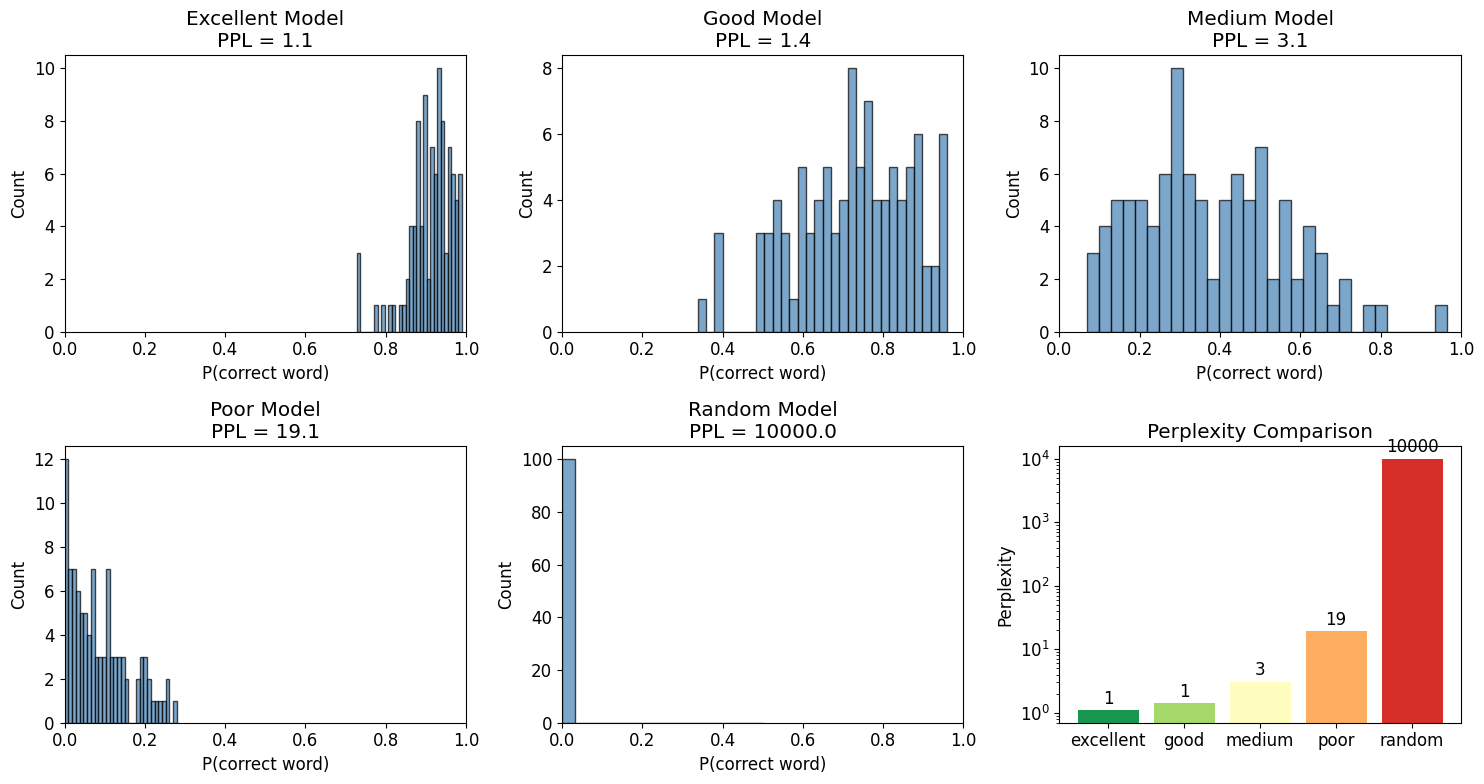


Perplexity Summary:
----------------------------------------
excellent   : PPL =      1.1
good        : PPL =      1.4
medium      : PPL =      3.1
poor        : PPL =     19.1
random      : PPL =  10000.0


In [17]:
# Visualize perplexity across different model qualities
def simulate_lm_quality(vocab_size=1000, seq_length=100, quality='good'):
    """
    Simulate a language model of varying quality and compute perplexity.
    
    Quality affects how peaked the probability distribution is.
    """
    np.random.seed(42)
    
    if quality == 'excellent':
        # Very confident, usually right
        probs = np.random.beta(20, 2, seq_length)
    elif quality == 'good':
        # Confident
        probs = np.random.beta(5, 2, seq_length)
    elif quality == 'medium':
        # Moderate confidence
        probs = np.random.beta(2, 3, seq_length)
    elif quality == 'poor':
        # Low confidence
        probs = np.random.beta(1, 10, seq_length)
    else:  # random
        probs = np.ones(seq_length) / vocab_size
    
    return probs, compute_perplexity(probs)

# Compare different quality levels
qualities = ['excellent', 'good', 'medium', 'poor', 'random']
vocab_size = 10000

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

results = []
for i, q in enumerate(qualities):
    probs, ppl = simulate_lm_quality(vocab_size=vocab_size, seq_length=100, quality=q)
    results.append((q, ppl))
    
    ax = axes[i]
    ax.hist(probs, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('P(correct word)')
    ax.set_ylabel('Count')
    ax.set_title(f'{q.capitalize()} Model\nPPL = {ppl:.1f}')
    ax.set_xlim(0, 1)

# Summary bar chart
ax = axes[5]
names = [r[0] for r in results]
ppls = [r[1] for r in results]
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(results)))
ax.bar(names, ppls, color=colors)
ax.set_ylabel('Perplexity')
ax.set_title('Perplexity Comparison')
ax.set_yscale('log')

# Add value labels
for i, (name, ppl) in enumerate(results):
    ax.text(i, ppl * 1.1, f'{ppl:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nPerplexity Summary:")
print("-" * 40)
for name, ppl in results:
    print(f"{name:12s}: PPL = {ppl:>8.1f}")

## Summary

In this notebook, we covered the key information theory concepts used in machine learning:

### 1. Self-Information and Entropy
- **Self-information**: $I(x) = -\log P(x)$ measures surprise
- **Entropy**: $H(X) = -\sum P(x)\log P(x)$ measures average uncertainty
- Maximum entropy = uniform distribution

### 2. KL Divergence
- Measures difference between distributions: $D_{KL}(P\|Q) = \sum P(x)\log\frac{P(x)}{Q(x)}$
- **Asymmetric**: forward KL vs reverse KL have different behaviors
- Used in VAEs as regularization term

### 3. Cross-Entropy
- $H(P,Q) = H(P) + D_{KL}(P\|Q)$
- **The standard classification loss function**
- Penalizes confident wrong predictions heavily

### 4. Mutual Information
- $I(X;Y) = H(X) - H(X|Y)$ measures shared information
- Detects **nonlinear dependencies** that correlation misses
- Used for feature selection and representation learning

### 5. Perplexity
- $PPL = 2^{H(P,Q)}$ measures language model quality
- Lower is better; represents "effective vocabulary uncertainty"

---

### Key Takeaways for Deep Learning:

| Concept | Where It Appears in ML |
|---------|------------------------|
| Cross-entropy | Classification loss (softmax + CE) |
| KL divergence | VAE loss, policy gradient methods |
| Entropy | Exploration bonuses, temperature scaling |
| Mutual information | Feature selection, InfoGAN, contrastive learning |
| Perplexity | Language model evaluation |

---

*Continue to Chapter 6 for SVD and dimensionality reduction...*